# Assignment 2 - Email Spam Classification

Classify the email using the binary classification method. Email Spam detection has two
states: 

1. Normal State – Not Spam, 
2. Abnormal State – Spam. 

Use K-Nearest Neighbors and Support Vector Machine for classification. Analyze their performance.

Dataset link: The emails.csv dataset on the Kaggle.
https://www.kaggle.com/datasets/balaka18/email-spam-classification-dataset-csv

In [3]:
import pandas as pd

In [5]:
df = pd.read_csv('./dataset/emails.csv')
df.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [6]:
df.isnull().sum()

Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64

In [7]:
df.drop('Email No.', inplace=True, axis=1)

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop('Prediction', axis=1)
y = df['Prediction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)


In [14]:
from sklearn.metrics import confusion_matrix, classification_report

print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\n\nKNN Classification Report: \n", classification_report(y_test, y_pred_knn))

KNN Confusion Matrix:
 [[614  92]
 [ 62 267]]


KNN Classification Report: 
               precision    recall  f1-score   support

           0       0.91      0.87      0.89       706
           1       0.74      0.81      0.78       329

    accuracy                           0.85      1035
   macro avg       0.83      0.84      0.83      1035
weighted avg       0.86      0.85      0.85      1035



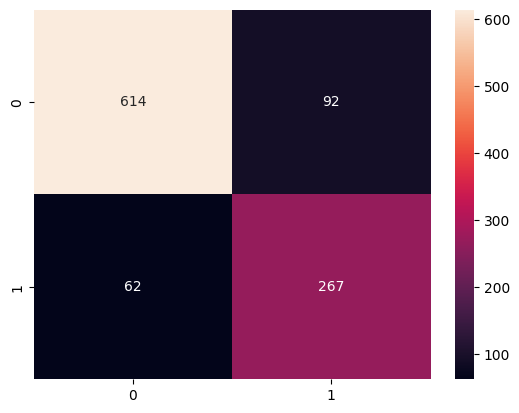

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt=".0f")
plt.show()

SVM

In [15]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [16]:
print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\n\nKNN Classification Report: \n", classification_report(y_test, y_pred_svm))

KNN Confusion Matrix:
 [[695  11]
 [ 26 303]]


KNN Classification Report: 
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       706
           1       0.96      0.92      0.94       329

    accuracy                           0.96      1035
   macro avg       0.96      0.95      0.96      1035
weighted avg       0.96      0.96      0.96      1035



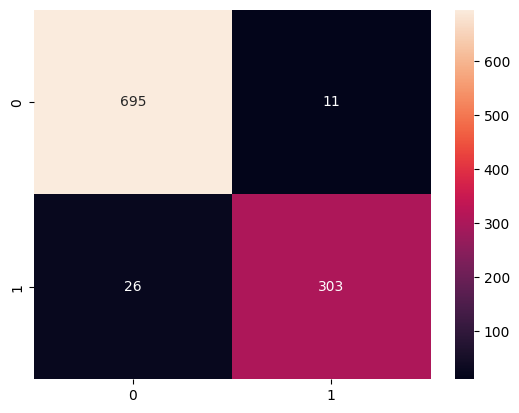

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt=".0f")
plt.show()